In [1]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [2]:
from pathlib import Path
import time
import random
import os
import numpy as np

# Env

In [3]:
def is_out_of_range(y: int, x: int, N:int)->bool:
    return not ((0 <= x < N) and (0 <= y < N))

In [4]:
def calc_mu_sigma(k:int, e:float, vs:int):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

In [5]:
class Env:
    IS_OUTPUT_FILE = True

    def __init__(self, file_path: str, exp_num: int):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2 * M :]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))

        self.N: int = N
        self.M: int = M
        self.esp: float = ESP
        self.grids: list[list[tuple[int, int]]] = GRID
        self.ans_grid: list[list[int]] = ANS_GRID

        self.total_oil_num: int = sum(len(g) for g in self.grids)
        self.score: int = 10**9

        cnt: int = 0
        for y in range(N):
            for x in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size: int = cnt

        self._sum_oil: int = 0
        self._score: float = 0

        self.plus_coordinates: list[tuple[int, int]] = []

        self.fixed_board: list[list[int]] = [[-1 for _ in range(N)] for _ in range(N)]

        self.queries1: list[tuple[tuple[int, int], int]] = []
        self.queries2: list[tuple[tuple[int, int], int]] = []
        
        self._out_file_path: Path = Path(f"../out/out{exp_num:0>4}.txt")
        if Env.IS_OUTPUT_FILE:
            if self._out_file_path.exists():
                os.remove(self._out_file_path)
            self._out_file_path.touch()

    def is_ok(self):
        return self._sum_oil == self.total_oil_num

    def query1(self, coordinate) -> int:
        y, x = coordinate
        self._score += 1
        resp: int = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        if Env.IS_OUTPUT_FILE:
            q = "q 1 {} {}".format(coordinate[0], coordinate[1])
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        resp = max(0, round(rng.normal(mu, sigma)))
        self._score += 1 / np.sqrt(k)
        self.queries2.append(resp)
        if Env.IS_OUTPUT_FILE:
            coordinate = []
            for y, x in coordinates:
                coordinate.append(y)
                coordinate.append(x)
            q = f"q {len(coordinates)} " + " ".join(map(str, coordinate))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp
    
    def answer(self, coordinates) -> bool:
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        if Env.IS_OUTPUT_FILE:
            q = "a {} {}".format(len(coordinates), " ".join(map(lambda k: "{} {}".format(k[0], k[1]), coordinates)))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return is_ok

    def answer_from_board(self, board: list[list[int]]) -> bool:
        has_oils: list[tuple[int, int]] = []
        for y in range(self.N):
            for x in range(self.N):
                if board[y][x] > 0:
                    has_oils.append((y, x))
        return self.answer(has_oils)

    @property
    def query1_count(self) -> int:
        return len(self.queries1)

# Run

In [6]:
env = Env(file_path = Path(f"../in/{0:0>4}.txt"), exp_num=0)

In [7]:
def search_placement_indexes(env: Env) -> list[list[tuple[int, int]]]:

    N: int = env.N
    M: int = env.M
    f_board: list[list[int]] = env.fixed_board
    grids: list[list[tuple[int, int]]] = env.grids

    placement_indexes: list[list[tuple[int, int]]] = []
    for m in range(M):
        now_grids: list[tuple[int, int]] = grids[m]
        now_placement_indexes: list[tuple[int, int]] = []
        is_m_indexes: list[tuple[int, int]] = []
        for y in range(N):
            for x in range(N):
                flag: bool = True
                max_diff = -1
                for coordinate in now_grids:
                    ny, nx = y + coordinate[0], x + coordinate[1]
                    if is_out_of_range(ny, nx, N) or f_board[ny][nx] == 0:
                        flag = False
                        break
                    max_diff = max(max_diff, f_board[ny][nx])
                if flag:
                    now_placement_indexes.append((y, x))
                    if max_diff == M:
                        is_m_indexes.append((y, x))
        if len(is_m_indexes) > 0:
            now_placement_indexes = is_m_indexes
        placement_indexes.append(now_placement_indexes)

    return placement_indexes

In [8]:
N = env.N
cnt_board = [[env.total_oil_num / N**2 for _ in range(N)] for _ in range(N)]

In [9]:
def get_all_coordinate(env: Env):
    all_coordinates = []
    for y in range(N):
        for x in range(N):
            if env.fixed_board[y][x] == -1:
                all_coordinates.append((y, x))
    return all_coordinates

In [10]:
import matplotlib.pyplot as plt

In [11]:
env._score

0

0


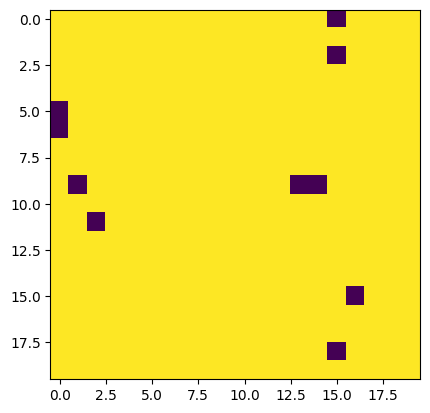

100


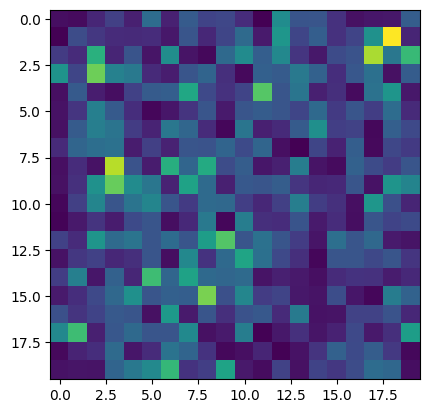

200


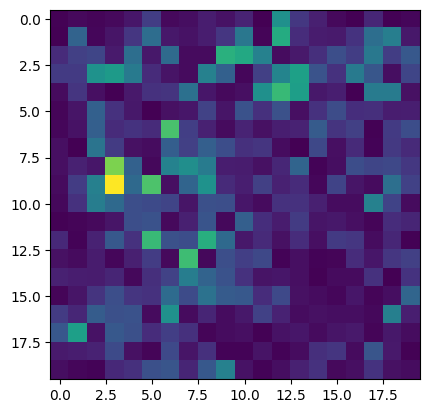

300


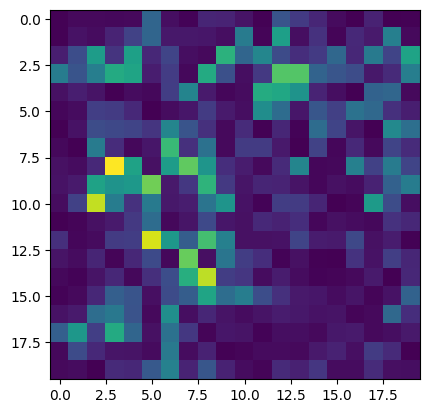

400


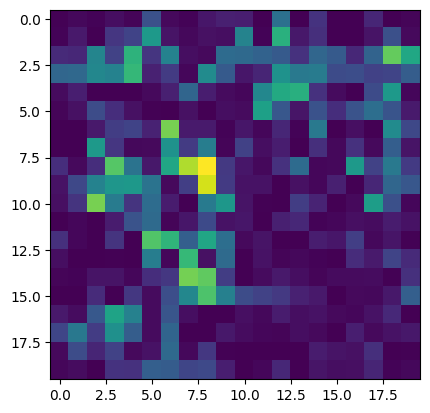

500


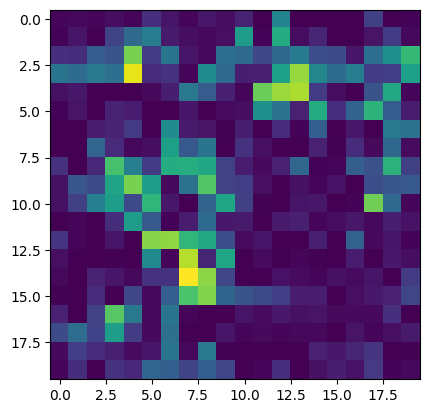

600


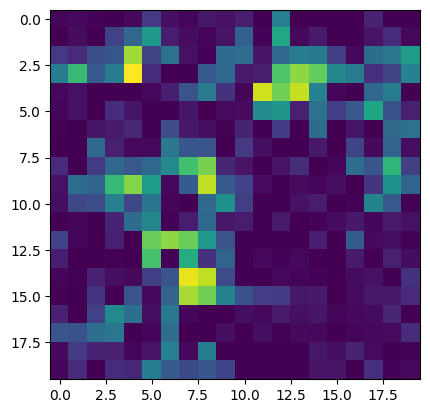

700


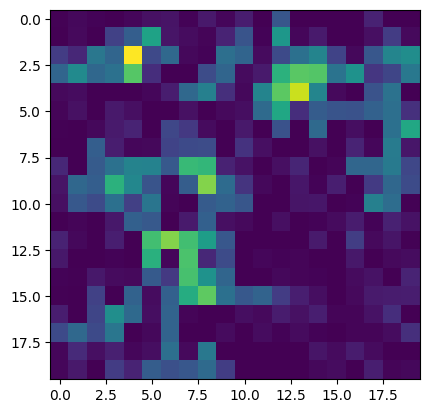

800


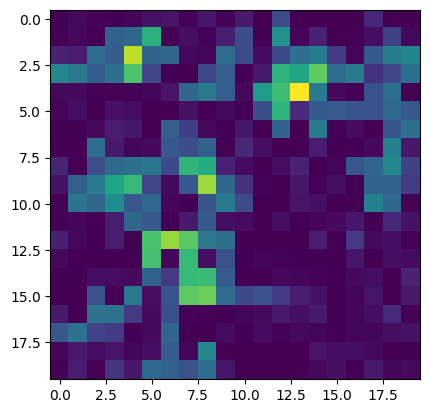

900


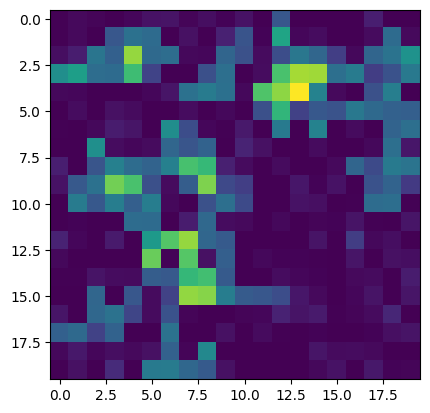

Done 1000000000


In [12]:
SIMULATE_N = 1000

for simulate_n in range(SIMULATE_N):
    
    all_coordinates_list = get_all_coordinate(env)
    all_coordinates = set(all_coordinates_list)
    # sample_k = len(all_coordinates) // 4
    sample_k = 10
    
    query_grids = set(random.sample(all_coordinates_list, sample_k))
    not_query_grids = all_coordinates - query_grids

    remain_oil_num = env.total_oil_num
    for y in range(N):
        for x in range(N):
            if env.fixed_board[y][x] > 0:
                remain_oil_num -= env.fixed_board[y][x]

    sample_sum = 0
    for y, x in query_grids:
        sample_sum += cnt_board[y][x]
    not_sample_sum = 0
    for y, x in not_query_grids:
        not_sample_sum += cnt_board[y][x]

    cnt = min(max(0.001, env.query2(query_grids)), remain_oil_num - 0.001)

    not_cnt = remain_oil_num - cnt

    for y, x in query_grids:
        cnt_board[y][x] *= cnt / sample_sum
    for y, x in not_query_grids:
        cnt_board[y][x] *= not_cnt / not_sample_sum
    
    max_grid = -1
    max_grid_coordinate = (-1, -1)
    for y, x in all_coordinates:
        if cnt_board[y][x] > max_grid:
            max_grid = cnt_board[y][x]
            max_grid_coordinate = (y, x)

    if env.is_ok():
        env.answer_from_board(env.fixed_board)
        break

    if simulate_n % 100 == 0:
        print(simulate_n)
        plt.imshow(cnt_board)
        plt.show()

print("Done", env.score)

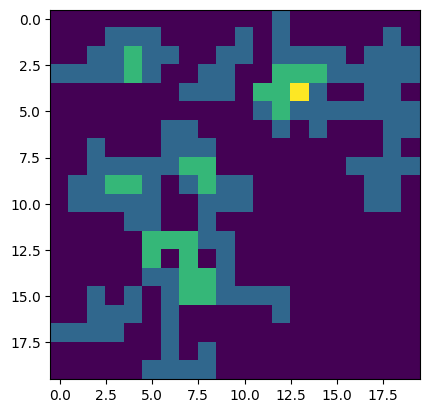

In [13]:
plt.imshow(env.ans_grid)
plt.show()

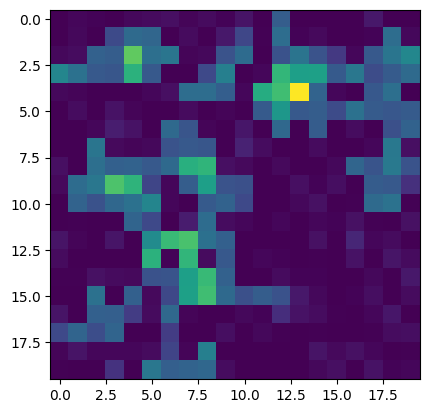

In [14]:
plt.imshow(cnt_board)
plt.show()

In [15]:
env._score

316.2277660168402